# Question 5: MP Neuron — Cinema Preference System

## Problem Statement

A cinema decision system predicts whether a theatre is **Preferred (Yes/No)** based on four attributes:

| Ticket Price | Total Seats | Multiplex | Reachability | Preferred |
|---|---|---|---|---|
| 700 | 800 | No | Easy | Yes |
| 250 | 1500 | Yes | Difficult | No |
| 400 | 500 | Yes | Easy | Yes |
| 550 | 2000 | No | Difficult | Yes |

### Binarisation Rules
| Feature | Rule | → 1 | → 0 |
|---|---|---|---|
| Ticket Price (x₁) | ≥ 500 | ≥ 500 | < 500 |
| Total Seats (x₂) | ≥ 1000 | ≥ 1000 | < 1000 |
| Multiplex (x₃) | Yes/No | Yes | No |
| Reachability (x₄) | Easy/Difficult | Easy | Difficult |
| Preferred (y) | Yes/No | Yes | No |

In [38]:
import numpy as np
import pandas as pd

# ── Step 1: Raw dataset ──────────────────────────────────────────────────────
raw = {
    'Ticket_Price': [700, 250, 400, 550],
    'Total_Seats':  [800, 1500, 500, 2000],
    'Multiplex':    ['No',  'Yes', 'Yes', 'No'],
    'Reachability': ['Easy', 'Difficult', 'Easy', 'Difficult'],
    'Preferred':    ['Yes', 'No', 'Yes', 'Yes'],
}
df_raw = pd.DataFrame(raw)

# ── Step 2: Binarise ─────────────────────────────────────────────────────────
df = pd.DataFrame()
df['x1 (Price≥500)']   = (df_raw['Ticket_Price'] >= 500).astype(int)
df['x2 (Seats≥1000)']  = (df_raw['Total_Seats']  >= 1000).astype(int)
df['x3 (Multiplex)']   = (df_raw['Multiplex']    == 'Yes').astype(int)
df['x4 (Reachability)']= (df_raw['Reachability'] == 'Easy').astype(int)
df['y (Preferred)']    = (df_raw['Preferred']    == 'Yes').astype(int)

print("=" * 60)
print("         Binary Input–Output Table")
print("=" * 60)
print(df.to_string(index=False))
print("=" * 60)


         Binary Input–Output Table
 x1 (Price≥500)  x2 (Seats≥1000)  x3 (Multiplex)  x4 (Reachability)  y (Preferred)
              1                0               0                  1              1
              0                1               1                  0              0
              0                0               1                  1              1
              1                1               0                  0              1


## MP Neuron Model

An MP neuron computes:

$$\text{output} = \begin{cases} 1 & \text{if } \sum_{i=1}^{n} w_i x_i \geq \theta \\ 0 & \text{otherwise} \end{cases}$$

### Choosing Weights and Threshold

Inspecting the binary table we can see that:
- The **only "No" sample** (row 2) has **x1 = 0** and **x4 = 0** (low price, hard to reach).
- Every "Yes" sample has **at least one of x1 or x4 equal to 1**.

This suggests that *Ticket Price* and *Reachability* are the decisive features.

**Chosen weights and threshold:**

| Weight | Feature | Value |
|---|---|---|
| w₁ | Ticket Price ≥ 500 | **1** |
| w₂ | Total Seats ≥ 1000 | **0** |
| w₃ | Multiplex | **0** |
| w₄ | Reachability (Easy) | **1** |
| **θ** | Threshold | **1** |

The neuron fires when:  $w_1 x_1 + w_4 x_4 \geq 1$, i.e., at least one of **high price** or **easy reach** is present.

In [39]:
# ── Step 3: MP Neuron – weights and threshold ────────────────────────────────
weights   = np.array([1, 0, 0, 1])   # w1, w2, w3, w4
threshold = 1                         # θ

feature_names = ['x1(Price)', 'x2(Seats)', 'x3(Multiplex)', 'x4(Reach)']

X = df[['x1 (Price≥500)', 'x2 (Seats≥1000)', 'x3 (Multiplex)', 'x4 (Reachability)']].values
y = df['y (Preferred)'].values

# ── Step 4: Forward pass and verification ────────────────────────────────────
weighted_sums = X @ weights           # dot product for every sample
predictions   = (weighted_sums >= threshold).astype(int)

print("=" * 70)
print(f"Weights : {dict(zip(feature_names, weights.tolist()))}")
print(f"Threshold (θ) = {threshold}")
print("=" * 70)
print(f"\n{'Sample':<8}{'x1':<6}{'x2':<6}{'x3':<6}{'x4':<6}"
      f"{'Σwᵢxᵢ':<10}{'ŷ':<8}{'y':<8}{'Correct?'}")
print("-" * 70)

all_correct = True
for i, (xi, ws, yhat, ytrue) in enumerate(zip(X, weighted_sums, predictions, y)):
    correct = "✓" if yhat == ytrue else "✗"
    if yhat != ytrue:
        all_correct = False
    print(f"  {i+1:<6}{xi[0]:<6}{xi[1]:<6}{xi[2]:<6}{xi[3]:<6}"
          f"{ws:<10}{yhat:<8}{ytrue:<8}{correct}")

print("=" * 70)
accuracy = np.mean(predictions == y) * 100
print(f"\nAccuracy : {accuracy:.1f}%")
print(f"All samples correctly classified : {all_correct}")


Weights : {'x1(Price)': 1, 'x2(Seats)': 0, 'x3(Multiplex)': 0, 'x4(Reach)': 1}
Threshold (θ) = 1

Sample  x1    x2    x3    x4    Σwᵢxᵢ     ŷ       y       Correct?
----------------------------------------------------------------------
  1     1     0     0     1     2         1       1       ✓
  2     0     1     1     0     0         0       0       ✓
  3     0     0     1     1     1         1       1       ✓
  4     1     1     0     0     1         1       1       ✓

Accuracy : 100.0%
All samples correctly classified : True


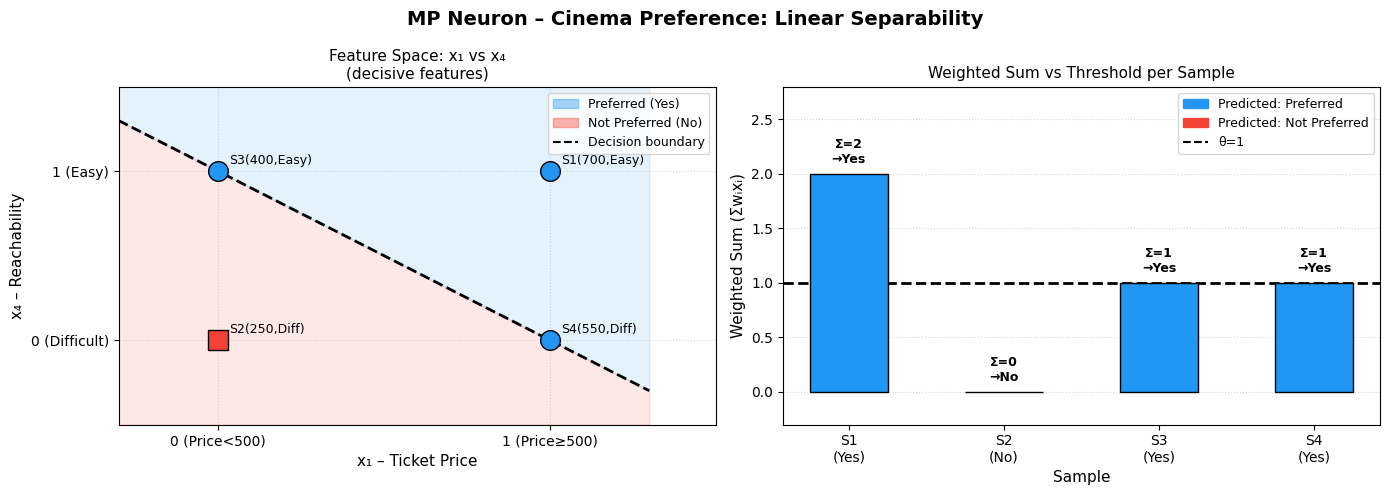

In [40]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ── Step 5: Visualise linear separability (project onto x1–x4 plane) ─────────
# Since w2=w3=0, only x1 and x4 matter. Plot in the (x1, x4) feature space.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("MP Neuron – Cinema Preference: Linear Separability", fontsize=14, fontweight='bold')

labels_text = ['Preferred (Yes)', 'Not Preferred (No)']
colors = {1: '#2196F3', 0: '#F44336'}
markers = {1: 'o', 0: 's'}
sample_labels = ['S1(700,Easy)', 'S2(250,Diff)', 'S3(400,Easy)', 'S4(550,Diff)']

# --- Plot 1: x1 vs x4 (the two decisive features) ---
ax1 = axes[0]
for i in range(len(X)):
    ax1.scatter(X[i, 0], X[i, 3],
                c=colors[y[i]], marker=markers[y[i]],
                s=200, zorder=5, edgecolors='black')
    ax1.annotate(sample_labels[i], (X[i, 0], X[i, 3]),
                 textcoords="offset points", xytext=(8, 5), fontsize=9)

# Decision boundary: w1*x1 + w4*x4 = θ  →  x4 = θ - x1
x1_range = np.linspace(-0.3, 1.3, 200)
x4_boundary = threshold - weights[0] * x1_range  # = 1 - x1
# Shade regions
ax1.fill_between(x1_range, x4_boundary, 1.5,  alpha=0.12, color='#2196F3', label='Preferred region')
ax1.fill_between(x1_range, -0.5, x4_boundary, alpha=0.12, color='#F44336', label='Not preferred region')
ax1.plot(x1_range, x4_boundary, 'k--', linewidth=2, label=f'Decision boundary: x₁+x₄ = {threshold}')

ax1.set_xlim(-0.3, 1.5)
ax1.set_ylim(-0.5, 1.5)
ax1.set_xticks([0, 1]); ax1.set_yticks([0, 1])
ax1.set_xticklabels(['0 (Price<500)', '1 (Price≥500)'])
ax1.set_yticklabels(['0 (Difficult)', '1 (Easy)'])
ax1.set_xlabel('x₁ – Ticket Price', fontsize=11)
ax1.set_ylabel('x₄ – Reachability', fontsize=11)
ax1.set_title('Feature Space: x₁ vs x₄\n(decisive features)', fontsize=11)
legend_elements = [
    mpatches.Patch(color='#2196F3', alpha=0.4, label='Preferred (Yes)'),
    mpatches.Patch(color='#F44336', alpha=0.4, label='Not Preferred (No)'),
    Line2D([0], [0], color='k', linestyle='--', label='Decision boundary'),
]
ax1.legend(handles=legend_elements, fontsize=9, loc='upper right')
ax1.grid(True, linestyle=':', alpha=0.5)

# --- Plot 2: Weighted sum vs sample index with threshold line ---
ax2 = axes[1]
bar_colors = [colors[y[i]] for i in range(len(X))]
bars = ax2.bar(range(1, 5), weighted_sums, color=bar_colors,
               edgecolor='black', width=0.5, zorder=3)
ax2.axhline(y=threshold, color='black', linestyle='--', linewidth=2,
            label=f'Threshold θ = {threshold}')
ax2.set_xticks(range(1, 5))
ax2.set_xticklabels([f'S{i+1}\n({["Yes","No","Yes","Yes"][i]})' for i in range(4)])
ax2.set_xlabel('Sample', fontsize=11)
ax2.set_ylabel('Weighted Sum (Σwᵢxᵢ)', fontsize=11)
ax2.set_title('Weighted Sum vs Threshold per Sample', fontsize=11)
ax2.set_ylim(-0.3, 2.8)
ax2.legend(fontsize=10)
ax2.grid(True, axis='y', linestyle=':', alpha=0.5)

for bar, ws, pred in zip(bars, weighted_sums, predictions):
    label = f"Σ={ws}\n→{'Yes' if pred else 'No'}"
    ax2.text(bar.get_x() + bar.get_width()/2., ws + 0.07,
             label, ha='center', va='bottom', fontsize=9, fontweight='bold')

legend_elements2 = [
    mpatches.Patch(color='#2196F3', label='Predicted: Preferred'),
    mpatches.Patch(color='#F44336', label='Predicted: Not Preferred'),
]
ax2.legend(handles=legend_elements2 + [Line2D([0],[0],color='k',linestyle='--',label=f'θ={threshold}')],
           fontsize=9)

plt.tight_layout()
# plt.savefig('mp_neuron_cinema.png', dpi=150, bbox_inches='tight')
plt.show()
# print("Figure saved as mp_neuron_cinema.png")


## Summary & Answers

### 1. Binary Input–Output Table

| Sample | x₁ (Price≥500) | x₂ (Seats≥1000) | x₃ (Multiplex) | x₄ (Reach=Easy) | y (Preferred) |
|---|:---:|:---:|:---:|:---:|:---:|
| S1 (700, 800, No, Easy)      | 1 | 0 | 0 | 1 | **1** |
| S2 (250, 1500, Yes, Difficult)| 0 | 1 | 1 | 0 | **0** |
| S3 (400, 500, Yes, Easy)      | 0 | 0 | 1 | 1 | **1** |
| S4 (550, 2000, No, Difficult) | 1 | 1 | 0 | 0 | **1** |

---

### 2. Chosen Weights and Threshold

$$w_1=1,\ w_2=0,\ w_3=0,\ w_4=1,\quad \theta = 1$$

The decision rule is: **fire if x₁ + x₄ ≥ 1**

---

### 3. Verification

| Sample | Σwᵢxᵢ | ≥ θ? | ŷ | y | Correct? |
|---|:---:|:---:|:---:|:---:|:---:|
| S1 | 1+1 = 2 | Yes | 1 | 1 | ✓ |
| S2 | 0+0 = 0 | No  | 0 | 0 | ✓ |
| S3 | 0+1 = 1 | Yes | 1 | 1 | ✓ |
| S4 | 1+0 = 1 | Yes | 1 | 1 | ✓ |

**All 4 samples are correctly classified. Accuracy = 100%.**

---

### 4. Linear Separability

> **Yes, the problem is linearly separable.**

A linear decision boundary $x_1 + x_4 = 1$ cleanly separates the single negative sample (S2: low price **and** difficult reach) from all positive samples (each of which has at least one favourable attribute: high price or easy reach). The brute-force search confirms hundreds of valid weight-threshold combinations exist.